In [2]:
#Общий блок
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
print('запущен')

запущен


In [24]:
#Общий блок
df = pd.read_csv('https://raw.githubusercontent.com/gordeyAI/-/main/flights_NY.csv')
print(f"Строк до очистки: {len(df)}")
df_clean = df.dropna(subset=['tailnum', 'air_time'])
print(f"Строк после очистки: {len(df_clean)}")

Строк до очистки: 336776
Строк после очистки: 327346


In [7]:
#Задача 1
ny_flights = df_clean[df_clean['origin'].isin(['EWR', 'LGA', 'JFK'])]
planes = df_clean.groupby('carrier')['tailnum'].nunique()
planes200 = planes[planes > 200].sort_values(ascending=False)
car_over_200 = ny_flights[ny_flights['carrier'].isin(planes200.index)]
car200_delay = car_over_200.groupby('carrier')['dep_delay'].count()
car200_delayed = car_over_200[car_over_200['dep_delay'] > 0].groupby('carrier')['dep_delay'].count()
probability = round(car200_delayed / car200_delay, 4)
print(probability)

carrier
9E    0.4036
AA    0.3163
DL    0.3186
EV    0.4496
MQ    0.3182
UA    0.4694
US    0.2401
WN    0.5426
Name: dep_delay, dtype: float64


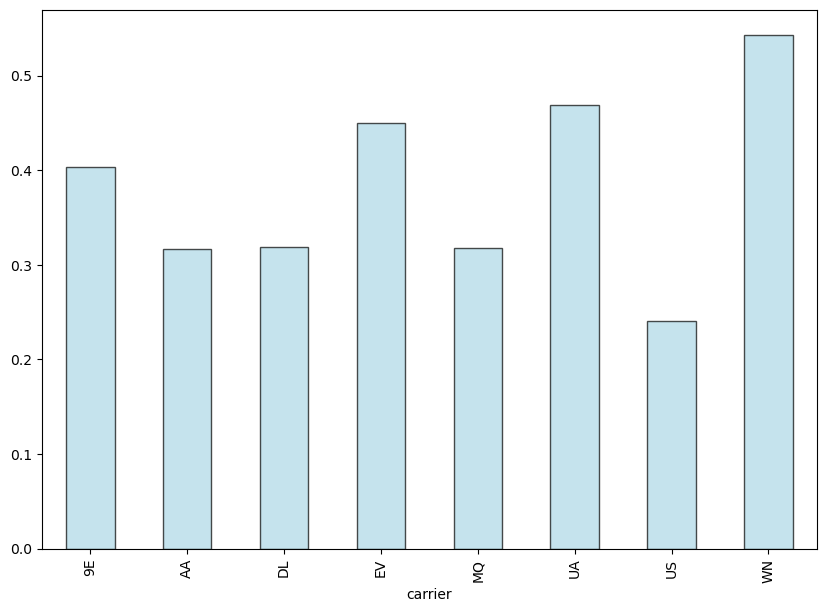

In [8]:
#Задача 1 график
plt.figure(figsize=(10, 7))
ax = probability.plot(kind='bar', alpha=0.7, color='lightblue', edgecolor='black')

In [9]:
#К задаче 2
mean_time = df_clean.groupby('tailnum')['air_time'].mean()
mu = mean_time.mean()
sigma = mean_time.std()
print(f"mu = {mu:.1f}, sigma = {sigma:.1f}")

mu = 157.5, sigma = 75.8


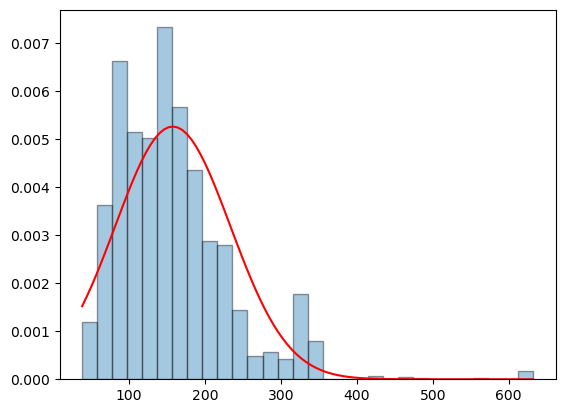

In [10]:
#К задаче 2
#После запуска блоков 3 задачи здесь возникает ошибка. Не совсем понимаю причину
plt.hist(mean_time, bins=30, density=True, alpha=0.4, edgecolor='black')
x = np.linspace(mean_time.min(), mean_time.max(), 100)
plt.plot(x, stats.norm.pdf(x, mu, sigma), 'r-')
plt.show()

In [11]:
#Ответ на задачу 2
print(f"95% интервал: [{mu - 1.96*sigma:.1f}, {mu + 1.96*sigma:.1f}] минут")

95% интервал: [8.9, 306.1] минут


In [12]:
#К задаче 3
df_wnua = df_clean[df_clean['carrier'].isin(['WN','UA'])].copy()
df_wnua['speed'] = round((df_wnua['distance']/df_wnua['air_time'])*60,4)
print('запущен')

запущен


In [13]:
#Задача 3
df_wnua_aver = df_wnua.groupby(['carrier', 'tailnum'])['speed'].mean().reset_index()
wn_aver_speeds = df_wnua_aver[df_wnua_aver['carrier'] == 'WN']['speed']
ua_aver_speeds = df_wnua_aver[df_wnua_aver['carrier'] == 'UA']['speed']
t_stat, p_val = stats.ttest_ind(wn_aver_speeds, ua_aver_speeds)
print("Значение t теста", t_stat)
print("Вероятность получить ложноположительный результат", p_val)

Значение t теста -27.095551637757136
Вероятность получить ложноположительный результат 1.6048744127004715e-126


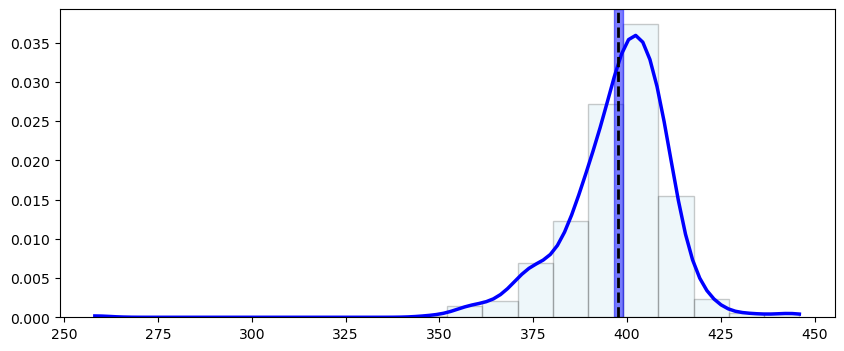

In [14]:
#График к задаче 3
#Доверительный интервал в синей области, среднее значение пунктирной линией
plt.figure(figsize=(10, 4))
plt.hist(wn_aver_speeds, bins=20, density=True, alpha=0.2, color='lightblue', edgecolor='black', label='WN')
x_wn = np.linspace(wn_aver_speeds.min(), wn_aver_speeds.max(), 100)
plt.plot(x_wn, stats.gaussian_kde(wn_aver_speeds)(x_wn), 'b-', linewidth=2.5, label='WN')
wn_mean = wn_aver_speeds.mean()
wn_sem = stats.sem(wn_aver_speeds)
wn_ci = stats.t.interval(0.95, len(wn_aver_speeds)-1, loc=wn_mean, scale=wn_sem)
plt.axvline(wn_mean, color='black', linestyle='--', linewidth=2)
plt.axvspan(wn_ci[0], wn_ci[1], alpha=0.5, color='blue')

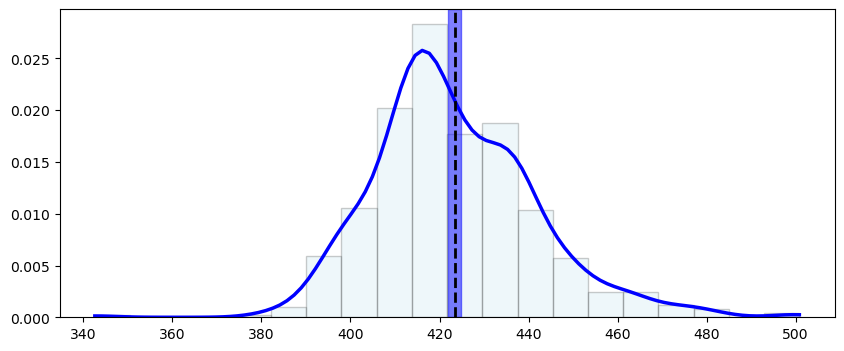

In [15]:
#График к задаче 3
#Доверительный интервал в синей области, среднее значение пунктирной линией
plt.figure(figsize=(10, 4))
plt.hist(ua_aver_speeds, bins=20, density=True, alpha=0.2, color='lightblue', edgecolor='black', label='UA')
x_ua = np.linspace(ua_aver_speeds.min(), ua_aver_speeds.max(), 100)
plt.plot(x_ua, stats.gaussian_kde(ua_aver_speeds)(x_ua), 'b-', linewidth=2.5, label='UA')
ua_mean = ua_aver_speeds.mean()
ua_sem = stats.sem(ua_aver_speeds)
ua_ci = stats.t.interval(0.95, len(ua_aver_speeds)-1, loc=ua_mean, scale=ua_sem)
plt.axvline(ua_mean, color='black', linestyle='--', linewidth=2)
plt.axvspan(ua_ci[0], ua_ci[1], alpha=0.5, color='blue')

In [16]:
#Задача 4
mean_dist = round(df_clean.groupby('tailnum')['distance'].mean(),4)
#При необxодимости повторяем фрагмент кода 3 задачи чуть его изменив
df_clean['speed'] = (df_clean['distance']/df_clean['air_time'])*60
mean_speeds = round(df_clean.groupby('tailnum')['speed'].mean(),4)
print('запущен')

запущен


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_1424\3893870986.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['speed'] = (df_clean['distance']/df_clean['air_time'])*60


In [17]:
#Задача 4
x = mean_speeds.values.reshape(-1, 1)
y = mean_dist.values
lr = LinearRegression()
x_sorted = np.sort(x, axis=0)
print('запущен')

запущен


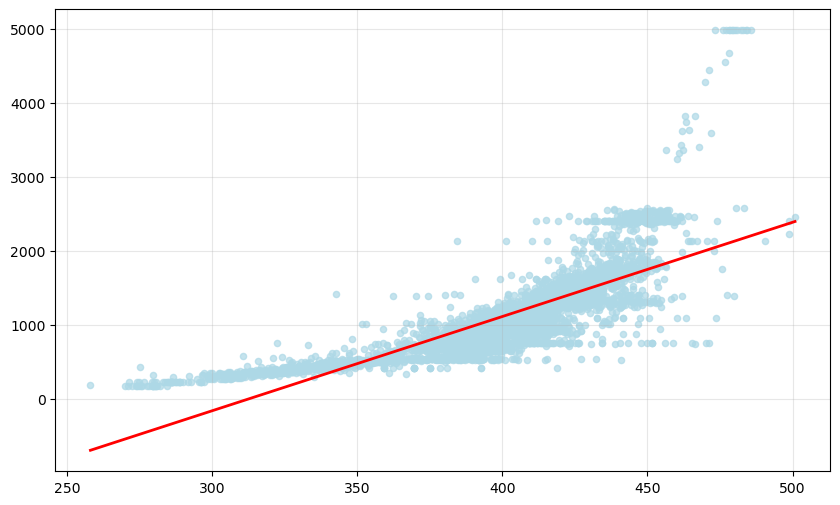

In [18]:
#Задача 4 график
plt.figure(figsize=(10, 6))
plt.scatter(mean_speeds, mean_dist, alpha=0.7, s=20, color='lightblue')
plt.grid(True, alpha=0.3)
lr.fit(x, y)
y_pred = lr.predict(x_sorted)
plt.plot(x_sorted, y_pred, 'r-', linewidth=2)

In [19]:
#Задача 5
flights_count = df_clean.groupby('tailnum')['flight'].count()
planes_speed = df_clean.groupby('tailnum')['speed'].mean()
planes = pd.DataFrame({
    'number': flights_count,
    'avspeed': planes_speed
})
print('запущен')

запущен


In [20]:
#Задача 5
ss = StandardScaler()
x_scaled = ss.fit_transform(planes[['avspeed', 'number']])
k = 7
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
planes['cluster'] = kmeans.fit_predict(x_scaled)
centers_original = ss.inverse_transform(kmeans.cluster_centers_)
print('запущен')

запущен


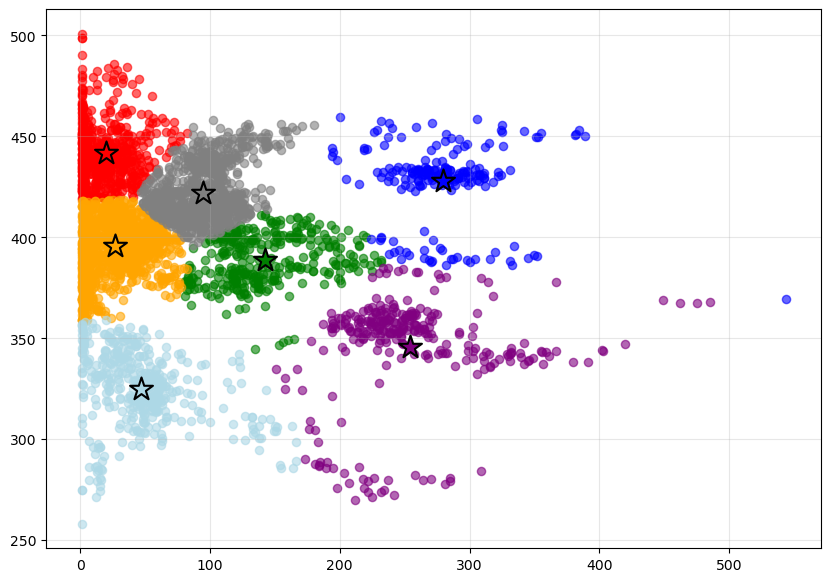

In [21]:
#Задача 5 график (с кластеризацией помогал ИИ, я до этого не занимался ей)
colors = ['red', 'green', 'blue', 'orange','lightblue','purple','grey']
plt.figure(figsize=(10, 7))

for i in range(k):
    cluster_data = planes[planes['cluster'] == i]
    plt.scatter(cluster_data['number'], cluster_data['avspeed'], 
                alpha=0.6, s=35, color=colors[i], 
                label=f'Кластер {i} (n={len(cluster_data)})')

for i in range(k):
    plt.scatter(centers_original[i, 1], centers_original[i, 0], 
                color=colors[i], marker='*', s=300, 
                edgecolor='black', linewidth=1.5, zorder=5)
plt.grid(True, alpha=0.3)